<a href="https://colab.research.google.com/github/shindesai125/Deep-Learning/blob/main/TransferLearning_FineTuning_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saimaheshshinde","key":"a325715bce9c2fdf514a64837354180b"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 86% 298M/346M [00:00<00:00, 927MB/s] 
100% 346M/346M [00:00<00:00, 734MB/s]


In [4]:
!unzip intel-image-classification.zip -d intel_image_data


Streaming output truncated to the last 5000 lines.
  inflating: intel_image_data/seg_train/seg_train/mountain/7506.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7537.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7539.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7551.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7560.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7565.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7578.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7581.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7586.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7647.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7652.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7654.jpg  
  inflating: intel_image_data/seg_train/seg_train/mountain/7662.jpg  
  inflating: intel_image_data/seg_train

In [5]:
import os

# Check the folders
base_path = "intel_image_data/seg_train/seg_train"
print("Classes:", os.listdir(base_path))


Classes: ['sea', 'buildings', 'forest', 'glacier', 'street', 'mountain']


In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

In [7]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150,150,3)
    )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
conv_base.trainable = True
set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable= False

for layer in conv_base.layers:
  print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [9]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [10]:
    from tensorflow.keras.layers import Dropout

In [11]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation = 'softmax'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,638 (64.14 MB)

 Trainable params: 9,178,374 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [13]:
conv_base.trainable = False

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img


In [15]:
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen=ImageDataGenerator(rescale=1./255)


train_generator=train_datagen.flow_from_directory(
    '/content/intel_image_data/seg_train/seg_train',
    target_size=(150,150),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator=test_datagen.flow_from_directory(
    '/content/intel_image_data/seg_test/seg_test',
    target_size=(150,150),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [16]:

# # generators
# train_ds = keras.utils.image_dataset_from_directory(
#     directory = '/content/intel_image_data/seg_train/seg_train',
#     labels='inferred',
#     label_mode = 'int',
#     batch_size=32,
#     image_size=(150,150)
# )

# validation_ds = keras.utils.image_dataset_from_directory(
#     directory = '/content/intel_image_data/seg_test/seg_test',
#     labels='inferred',
#     label_mode = 'int',
#     batch_size=32,
#     image_size=(150,150)
# )

In [17]:
# # Normalizing values between 0 and 1
# def process(image,label):
#   image = tensorflow.cast(image/255. ,tensorflow.float32)
#   return image,label

# train_ds=train_ds.map(process)
# validation_ds=validation_ds.map(process)

In [18]:
model.compile(optimizer=tensorflow.keras.optimizers.RMSprop(learning_rate = 1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 119s 250ms/step - accuracy: 0.3767 - loss: 1.5610 - val_accuracy: 0.7830 - val_loss: 0.6916
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 224ms/step - accuracy: 0.7246 - loss: 0.7668 - val_accuracy: 0.8283 - val_loss: 0.5326
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - accuracy: 0.7753 - loss: 0.6188 - val_accuracy: 0.8317 - val_loss: 0.4723
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 223ms/step - accuracy: 0.7971 - loss: 0.5639 - val_accuracy: 0.8397 - val_loss: 0.4409
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 223ms/step - accuracy: 0.8177 - loss: 0.5113 - val_accuracy: 0.8510 - val_loss: 0.4146
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 223ms/step - accuracy: 0.8311 - loss: 0.4851 - val_accuracy: 0.8543 - val_loss: 0.4039
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 224ms/step - accuracy: 0.8312 - loss: 0.4726 - val_accuracy: 0.8553 - val_loss: 0.3903
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 98s 223ms/step - accuracy: 0.8347 - loss: 

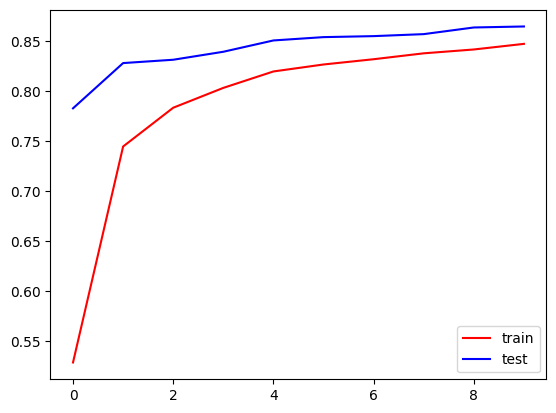

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='test')
plt.legend()
plt.show()

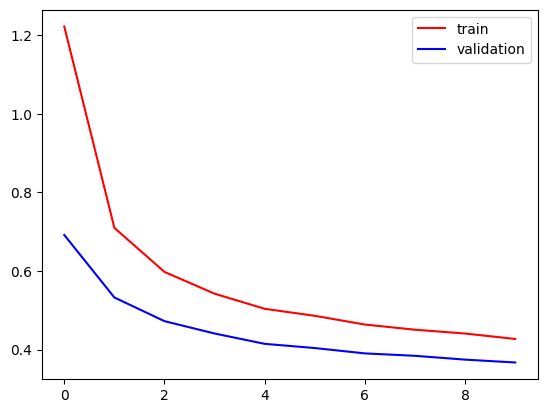

In [23]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()